# **StockGuard_for_youtube — Modeling**

전처리 산출물(`data/processed/`, preprocessing.ipynb)을 입력으로 3개 가설 검증.

**방법 출처**: 응용데이터분석 강의자료·실습코드 — 05 Classification(분류기·train/test 분리·confusion matrix·ROC-AUC), 06 Ensemble(RandomForest), 07 Clustering(KMeans·silhouette), 09 Statistics(t-test·Mann-Whitney·ANOVA).
**도메인 근거**: KCMI 이슈보고서 21-05(유튜브 주식채널의 정보효과와 위험요인), 금융위 보도자료 2024.8.14(유사투자자문 불건전영업 규율), 금감원 불법금융신고센터(fine.fss.or.kr).

### **0. 환경 설정 & 데이터 load**

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

plt.rcParams['font.family'] = 'NanumGothic' # 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

P = Path('/home/songyaeji/stockguard_for_youtube/data/processed')
cf  = pd.read_csv(P / 'channel_features.csv')                 # 채널 feature 매트릭스 (ML 입력)
lab = pd.read_csv(P / 'channel_labels.csv')                   # search_query — 평가·prior 전용(누수 차단)
chc = pd.read_csv(P / 'channels_clean.csv')                   # 라벨 생성용 채널 description
vdc = pd.read_csv(P / 'videos_clean.csv', usecols=['channel_id', 'title', 'description'])
print(f'channel_features {cf.shape} | labels {lab.shape} | channels {chc.shape} | videos {vdc.shape}')

channel_features (2214, 46) | labels (2214, 3) | channels (2214, 20) | videos (32972, 3)


### **1. 분석 프레임 — 데이터 분석가 관점**

이 분석이 풀려는 건 모델 정확도 경쟁이 아니라 **차단 의사결정 문제**. 최종 산출물(크롬 익스텐션)은 채널마다 차단 / 경고 / 통과 중 하나를 골라야 함.

**오류 비용의 비대칭**
- 오차단(false positive) = 정상 채널을 막음 → 사용자 신뢰 훼손 + 채널 운영자 피해(법적 리스크). 비용 큼.
- 미탐(false negative) = 리딩방 통과 → 시청자 피해 지속. 비용 있으나 경고·신고 등 보완 수단 존재.
- → **차단은 precision 우선, 경고는 recall 허용**. 단일 정확도 수치로 판단하지 않고 운영점(threshold)별로 따로 평가.

**모집단과 일반화 한계**: 분석 대상 = 30개 주식 검색어로 수집된 채널 2,214개. 경제 유튜브 전체가 아니므로 결론도 이 범위 안에서만 유효(7장 배포 설계에서 처리).

**leakage 규칙(사전 고정)**
- `search_query` = 수집 키워드 = 약한 라벨 prior → feature 금지, 평가·prior 용도만.
- 금융위 규제어 = 라벨(y) 근거 → feature로 쓰면 regex 재학습(순환). 텍스트 의미축(`desc_pca_*`)도 규제어를 간접 포함할 수 있어 본검증에서 제외, ablation으로만 비교.

**사전 판정기준 (가설 먼저, 모델 나중 — 결과 보고 기준 바꾸지 않음)**

| 가설 | 방법 | 채택 기준 |
|---|---|---|
| H1 리딩방은 규제키워드 없이도 행동·구조 패턴으로 판별 가능 | 지도학습 분류 (RandomForest, LogisticRegression) | holdout recall ≥ 0.7 그리고 F1 ≥ 0.6 |
| H2 작전성 채널은 참여·구조 지표 공간에서 별도 군집으로 분리 | 표준화 → PCA → KMeans | 군집–시드라벨 ARI ≥ 0.2 |
| H3 의심군의 참여율·시황민감도는 정상군과 다름 | Welch t-test + Mann-Whitney + ANOVA | p < 0.05 (α 사전 고정) 그리고 \|Cohen's d\| ≥ 0.5 |

기각도 정당한 결과 — 목표는 정확도가 아닌 insight.

### **2. 시드 라벨 구축 — 규제어 기반(공식 근거)**

골드라벨(전문가 검수) 부재 → 규제기관이 명시한 표현으로 시드 라벨 생성. 규제어 = **라벨 근거**지 feature 아님.

| 규제어 | 출처 |
|---|---|
| 수익률·원금 보장, 손실 보전 | 금융위 금지광고(2024.8.14 보도자료) |
| VIP 방·종목·회원 | 금융위 금지광고(VIP 종목) |
| 리딩방, 무료 리딩 | 금융위·금감원 규제 대상 |
| 종목 추천, 추천주 | 금감원 불법유형(종목추천 대가 수취) |
| 자동매매 | 금감원 불법유형(자동매매프로그램 판매) |

**라벨 규칙**: 채널 description + 그 채널 영상 제목·설명 합본에서
- 서로 다른 규제어 2종 이상 **또는** 총 5회 이상(도배) → `suspect` 시드
- 0회 → `normal` 시드
- 그 외(단일 유형 1~4회) → 회색지대, 학습 제외 — 뉴스·사기 주의 환기 채널이 1~2회 언급으로 오염되는 것 방지

In [2]:
REG = {
    '수익보장': r'수익률?\s*보장|원금\s*보장|손실\s*보전',
    'VIP'    : r'VIP\s*(?:방|반|종목|클럽|멤버|회원)|브이아이피',
    '리딩방' : r'리딩\s*방|주식\s*리딩|무료\s*리딩',
    '종목추천': r'종목\s*추천|추천\s*종목|추천주',
    '자동매매': r'자동\s*매매',
}
vdc['txt'] = vdc['title'].fillna('') + ' ' + vdc['description'].fillna('')
vtext = vdc.groupby('channel_id')['txt'].apply(' '.join)
text = (chc['description'].fillna('') + ' ' + chc['channel_id'].map(vtext).fillna('')).set_axis(chc['channel_id'])

H = pd.DataFrame({k: text.str.count(p, flags=re.I) for k, p in REG.items()})
H['kinds'] = (H[list(REG)] > 0).sum(axis=1)
H['total'] = H[list(REG)].sum(axis=1)

seed = pd.Series('unlabeled', index=H.index)
seed[H['total'] == 0] = 'normal'
seed[(H['kinds'] >= 2) | (H['total'] >= 5)] = 'suspect'

# 검색어 그룹(A=리딩방 타겟 12 / B=정상 타겟 12 / C=교차 6) — 평가·prior 전용
A = ['주식리딩방','주식종목추천','급등주','수익률보장','오늘의추천주','무료리딩',
     '단타매매','주식자동매매','주식투자방법','테마주','주식대박','VIP종목']
B = ['주식투자','주식시장','경제전망','기업분석','코스피','코스닥',
     '주식시황','재테크','주식공부','애널리스트','ETF투자','미국주식']
grp = lab.set_index('channel_id')['search_query'].map(lambda q: 'A' if q in A else ('B' if q in B else 'C'))

cf['seed'] = cf['channel_id'].map(seed)
cf['q_group'] = cf['channel_id'].map(grp)

print(cf['seed'].value_counts().to_dict())
print('\n검색어 그룹별 시드 분포(행 비율):')
print(pd.crosstab(cf['q_group'], cf['seed'], normalize='index').round(3))
print('\n의심 시드 상위(규제어 총 매칭순) — 눈 검증:')
top_sus = H.loc[seed == 'suspect'].nlargest(8, 'total')
display(top_sus.join(chc.set_index('channel_id')['title'])[['title', 'kinds', 'total']])

{'normal': 1428, 'suspect': 424, 'unlabeled': 362}

검색어 그룹별 시드 분포(행 비율):
seed     normal  suspect  unlabeled
q_group                            
A         0.415    0.341      0.244
B         0.841    0.067      0.092
C         0.765    0.106      0.129

의심 시드 상위(규제어 총 매칭순) — 눈 검증:


,title,kinds,total
channel_id,,,
UCPbb_OLIxmqelxxHSIEjJAg,"통통주식TV= (단타,스윙)검색기+자동매매",3,370
UCYslozpPZoYEgPtn18vCucQ,업리치- 비트코인자동매매 No.1,1,156
UCdruNV1JV05WIas8L9zQaiA,주식천국 [소액투자자 전문지원],2,152
UCDOAILOwtCXMAPj2sLuLA1w,40대 아빠의 재테크,2,140
UCYJSLwjCoUEbSsc5mP74Pqw,실크로드자동매매,1,139
UCLaxMxEo0VoRvJ4ZAh4X2cg,FX자동매매 수익재태크,2,138
UCmeKw0rCkr2XRTVXcmrlllw,슈퍼개미주식투자TV,3,122
UC5JYQZwCn8uoxBpAA8yonaw,천만수익-해외선물자동매매프로그램오토로봇,1,122


**시드 결과**: suspect 424 / normal 1,428 / 회색 362. A그룹(리딩방 타겟 검색어) 채널의 의심 시드율 34% vs B그룹(정상 타겟) 7% — 수집 prior와 방향 일치. `search_query`는 라벨 생성에 안 썼으므로 순환 아님, 시드 타당성의 독립 방증.

**한계**: 시드 = 규제어 휴리스틱이지 골드라벨 아님. 리딩방 폭로·주의 환기 채널이 일부 섞일 수 있음 → 회색지대 분리로 완화, 8장 한계에 재명시.

### **3. H1 — 지도학습 분류**

**가설**: 리딩방 의심 채널은 명시적 규제키워드 없이도 행동·구조 패턴(참여율, 업로드 시간대, 댓글 행동, 연락처 형식 플래그 등)으로 판별 가능.
**판정기준(사전 선언)**: holdout recall ≥ 0.7 그리고 F1 ≥ 0.6.
**방법 근거**: 강의 05 Classification(train/test 분리, LogisticRegression, confusion matrix, ROC-AUC)·06 Ensemble(RandomForest). 클래스 불균형 약 3.4:1 → `class_weight='balanced'`.
**feature**: 행동·구조·형식 36개. `desc_pca_*`(텍스트 의미축)는 규제어 간접 누수 가능 → 본검증 제외, ablation 비교만. baseline = A그룹 수집 여부로 의심 판정(검색 prior 단독).

LogReg         recall=0.679  precision=0.409  F1=0.511  AUC=0.742
RandomForest   recall=0.491  precision=0.553  F1=0.520  AUC=0.806
baseline(A수집)  recall=0.717  precision=0.463  F1=0.563


RF+desc_pca    recall=0.538  precision=0.528  F1=0.533  AUC=0.810


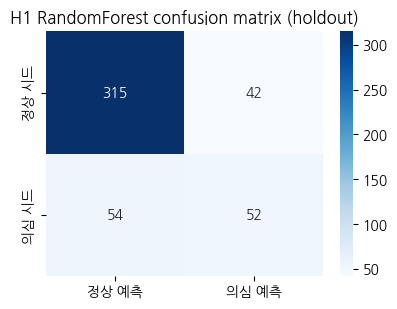

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (recall_score, precision_score, f1_score, roc_auc_score,
                             confusion_matrix, precision_recall_curve)

text_cols = [c for c in cf.columns if c.startswith('desc_pca_')]
drop_cols = ['channel_id', 'title', 'seed', 'q_group'] + text_cols
X_cols = [c for c in cf.columns if c not in drop_cols]
med = cf[X_cols].median(numeric_only=True)   # 결측(댓글 없는 채널 등) = 중앙값 채움

m = cf['seed'] != 'unlabeled'
X = cf.loc[m, X_cols].fillna(med)
y = (cf.loc[m, 'seed'] == 'suspect').astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

sc = StandardScaler().fit(X_tr)
lr = LogisticRegression(max_iter=1000, class_weight='balanced').fit(sc.transform(X_tr), y_tr)
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42).fit(X_tr, y_tr)

def report(name, y_pred, y_score):
    print(f'{name:14s} recall={recall_score(y_te, y_pred):.3f}  precision={precision_score(y_te, y_pred):.3f}  '
          f'F1={f1_score(y_te, y_pred):.3f}  AUC={roc_auc_score(y_te, y_score):.3f}')

report('LogReg', lr.predict(sc.transform(X_te)), lr.predict_proba(sc.transform(X_te))[:, 1])
report('RandomForest', rf.predict(X_te), rf.predict_proba(X_te)[:, 1])

base_pred = (cf.loc[y_te.index, 'q_group'] == 'A').astype(int)   # baseline: 검색 prior 단독
print(f'{"baseline(A수집)":14s} recall={recall_score(y_te, base_pred):.3f}  '
      f'precision={precision_score(y_te, base_pred):.3f}  F1={f1_score(y_te, base_pred):.3f}')

# ablation: desc_pca 포함 시 변화
Xa_cols = X_cols + text_cols
meda = cf[Xa_cols].median(numeric_only=True)
Xa = cf.loc[m, Xa_cols].fillna(meda)
rfa = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42).fit(Xa.loc[X_tr.index], y_tr)
report('RF+desc_pca', rfa.predict(Xa.loc[X_te.index]), rfa.predict_proba(Xa.loc[X_te.index])[:, 1])

cm_ = confusion_matrix(y_te, rf.predict(X_te))
plt.figure(figsize=(4, 3.2))
sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues',
            xticklabels=['정상 예측', '의심 예측'], yticklabels=['정상 시드', '의심 시드'])
plt.title('H1 RandomForest confusion matrix (holdout)')
plt.tight_layout(); plt.show()

precision ≥ 0.7: threshold=0.64  recall=0.283
precision ≥ 0.9: threshold=0.71  recall=0.217


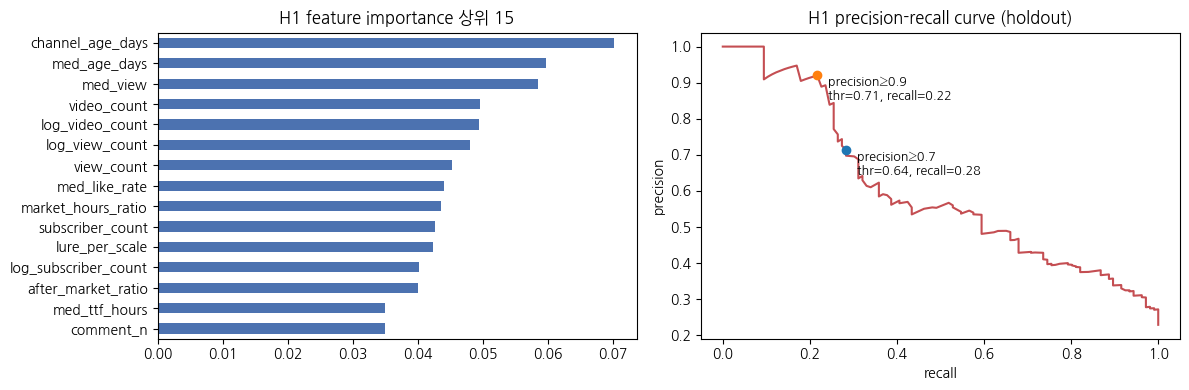

In [4]:
score_te = rf.predict_proba(X_te)[:, 1]
prec, rec, thr = precision_recall_curve(y_te, score_te)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
imp = pd.Series(rf.feature_importances_, index=X_cols).sort_values().tail(15)
imp.plot(kind='barh', ax=ax[0], color='#4c72b0')
ax[0].set_title('H1 feature importance 상위 15')

ax[1].plot(rec, prec, color='#c44e52')
for pt in [0.7, 0.9]:                       # 익스텐션 운영점 후보: 경고층 / 차단층
    i = min(int(np.argmax(prec >= pt)), len(thr) - 1)   # prec[i]는 thr[i]에 대응 — thr[i-1]이면 목표 precision 미달
    ax[1].scatter(rec[i], prec[i], zorder=3)
    ax[1].annotate(f'precision≥{pt}\nthr={thr[i]:.2f}, recall={rec[i]:.2f}',
                   (rec[i], prec[i]), textcoords='offset points', xytext=(8, -18), fontsize=9)
    print(f'precision ≥ {pt}: threshold={thr[i]:.2f}  recall={rec[i]:.3f}')
ax[1].set_xlabel('recall'); ax[1].set_ylabel('precision'); ax[1].set_title('H1 precision-recall curve (holdout)')
plt.tight_layout(); plt.show()

In [5]:
# regex가 못 보는 회피형 후보: 회색지대(규제어 1~4회 단일 유형) 중 모델 점수 상위
um = cf['seed'] == 'unlabeled'
cf.loc[um, 'rf_score'] = rf.predict_proba(cf.loc[um, X_cols].fillna(med))[:, 1]
display(cf.loc[um].nlargest(8, 'rf_score')[['title', 'rf_score']])

,title,rf_score
1453,주식가치 판단가,0.990000
1460,김용진,0.983333
1418,주식가치 평론가,0.980000
679,투자입문 채널,0.960000
1488,시장읽기,0.960000
1617,경제공부 주식채널,0.956667
2120,초보주식 길라잡이,0.940000
2058,경제흐름 투자전문,0.936667


**H1 판정 = 기각.** RandomForest holdout recall 0.49, F1 0.52 — 사전 기준(recall ≥ 0.7, F1 ≥ 0.6) 미달. baseline(A그룹 수집 여부 단독, recall 0.72·F1 0.56)조차 못 넘음 → 행동·구조 신호만으로 규제어 시드 라벨을 재현하기엔 부족. ablation(desc_pca 포함)도 AUC +0.004 수준이라 텍스트 의미축의 추가 기여 미미.

**그래도 남는 것 (데이터 분석가 관점)**
- AUC 0.81 = 이진 분류기로는 약해도 **순위(의심 점수) 능력은 유효**. 차단/통과 2분법 대신 점수 기반 다층 대응으로 용도 전환.
- precision-recall 운영점: precision ≥ 0.9에서 threshold 0.71·recall 0.22 — "확실한 것만 차단"층. precision ≥ 0.7에서 threshold 0.64·recall 0.28 — 경고층. 오차단 비용이 큰 차단 의사결정 구조와 정합(1장).
- 회피형 탐지 가치: 규제어 회색지대 채널 중 점수 0.9 이상 다수("주식가치 판단가", "투자입문 채널" 등 전형적 봇 작명 패턴) — **regex 단독으로는 안 잡히는 후보를 모델이 제시** = ML이 키워드 필터를 넘어서는 지점.
- 상위 feature가 채널 나이·영상 나이·규모 계열 → 신생·저참여 구조 신호가 판별 축. 단 시드 라벨 noise(휴리스틱)가 성능 상한을 누르고 있을 가능성 — 골드라벨 확보가 1순위 개선책.

### **4. H2 — 비지도 PCA + 군집**

**가설**: 작전성 채널은 참여·구조 지표 공간에서 별도 군집으로 분리.
**판정기준(사전 선언)**: 군집–시드라벨 ARI ≥ 0.2.
**방법 근거**: 강의 07 Clustering(KMeans, silhouette). 표준화 후 PCA 10축으로 줄이고 k는 silhouette 최대값으로 선택. 시드 라벨은 군집 형성에 미사용 — 사후 평가에만.

PCA 10축 누적 설명분산: 0.652


silhouette: {2: 0.242, 3: 0.242, 4: 0.255, 5: 0.256, 6: 0.243, 7: 0.218, 8: 0.236} → k = 5


ARI = 0.047 (기준 0.2) | 전체 의심 시드율 0.229


,n,suspect_rate,농축배율
cluster,,,
0,853,0.152,0.67
1,819,0.264,1.15
2,2,0.000,0.00
3,41,0.195,0.85
4,137,0.511,2.23


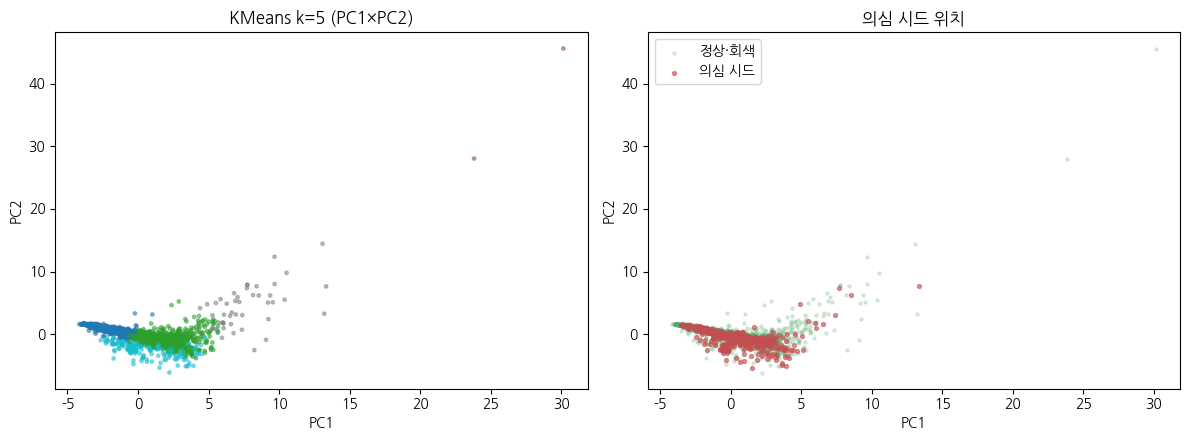

In [6]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

Z = StandardScaler().fit_transform(cf[X_cols].fillna(med))
pca = PCA(n_components=10, random_state=42)
Zp = pca.fit_transform(Z)
print(f'PCA 10축 누적 설명분산: {pca.explained_variance_ratio_.sum():.3f}')

sils = {}
for k in range(2, 9):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Zp)
    sils[k] = silhouette_score(Zp, km_k.labels_)
best_k = max(sils, key=sils.get)
print('silhouette:', {k: round(v, 3) for k, v in sils.items()}, '→ k =', best_k)

km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Zp)
cf['cluster'] = km.labels_

lm = cf['seed'] != 'unlabeled'
ari = adjusted_rand_score((cf.loc[lm, 'seed'] == 'suspect').astype(int), cf.loc[lm, 'cluster'])
base_rate = (cf.loc[lm, 'seed'] == 'suspect').mean()
print(f'ARI = {ari:.3f} (기준 0.2) | 전체 의심 시드율 {base_rate:.3f}')
tbl = cf[lm].groupby('cluster').agg(n=('seed', 'size'), suspect_rate=('seed', lambda s: (s == 'suspect').mean()))
tbl['농축배율'] = (tbl['suspect_rate'] / base_rate).round(2)
display(tbl.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(Zp[:, 0], Zp[:, 1], c=km.labels_, cmap='tab10', s=6, alpha=0.5)
ax[0].set_title(f'KMeans k={best_k} (PC1×PC2)')
sus_m = (cf['seed'] == 'suspect').values
ax[1].scatter(Zp[~sus_m, 0], Zp[~sus_m, 1], s=5, alpha=0.2, color='#55a868', label='정상·회색')
ax[1].scatter(Zp[sus_m, 0], Zp[sus_m, 1], s=8, alpha=0.6, color='#c44e52', label='의심 시드')
ax[1].set_title('의심 시드 위치'); ax[1].legend()
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()

**H2 판정 = 기각.** ARI 0.05 — 기준(0.2)에 크게 미달, 의심 채널이 별도 군집으로 깨끗이 분리되지 않음. silhouette도 0.26 수준이라 군집 구조 자체가 또렷하지 않음.

**그래도 남는 것**: 한 군집(n≈140)에 의심 시드가 51% 농축 — 전체 시드율 23%의 약 2.2배. 완전 분리는 아니지만 의심 채널이 모이는 밀집 지역은 존재. 데이터 분석가 관점에서 군집은 차단 근거가 아니라 **수동 검토 우선순위 큐**로 쓰는 게 맞음(농축 군집부터 검토 → 라벨링 비용 절감). "참여·구조 공간만으로는 부족"이라는 기각 자체가 H1의 feature 한계와 일관된 insight.

### **5. H3 — 통계검정**

**가설**: 의심군의 참여율(`med_comment_rate`)·시황민감도(`market_hours_ratio` = 장중 9~15시 업로드 비율)는 정상군과 다름.
**판정기준(사전 선언)**: p < 0.05 (α 사전 고정) 그리고 |Cohen's d| ≥ 0.5.
**방법 근거**: 강의 09 Statistics(ttest_ind, mannwhitneyu, f_oneway). 참여율 분포가 오른쪽으로 치우침(전처리 EDA) → Welch t-test에 Mann-Whitney 비모수 병행, 두 검정이 일치할 때만 신뢰. 시황민감도 변수는 KCMI 21-05(개장 전후 방송 패턴, 지수 변동–조회수 상관)에서 채택.

,변수,의심 평균,정상 평균,welch_p,mw_p,cohen_d
0,med_comment_rate,0.0042,0.0074,0.0490,0.7921,-0.0643
1,market_hours_ratio,0.3398,0.3047,0.0148,0.0004,0.1277
2,med_ttf_hours,657.4369,213.3642,0.0943,0.8975,0.1697


ANOVA market_hours_ratio (A/B/C): F=10.75  p=2.3e-05  그룹평균=[np.float64(0.3557), np.float64(0.2978), np.float64(0.3027)]
ANOVA med_comment_rate (A/B/C): F=0.41  p=6.6e-01  그룹평균=[np.float64(0.0091), np.float64(0.0071), np.float64(0.0063)]


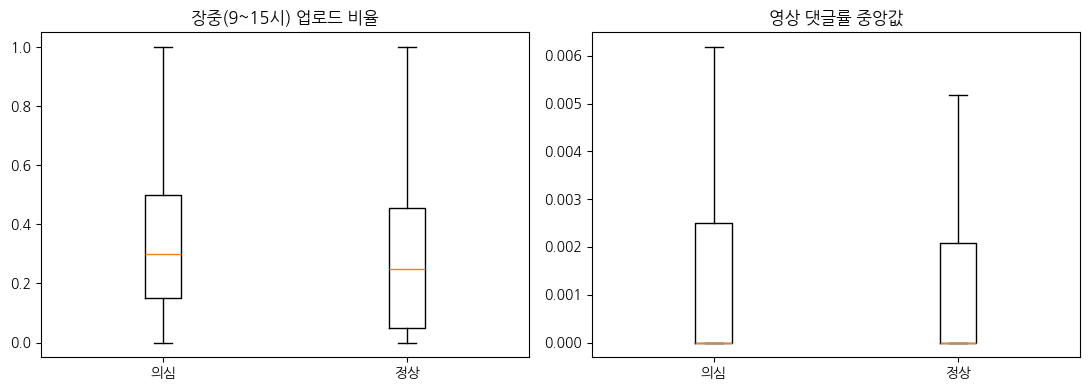

In [7]:
def cohens_d(a, b):
    a, b = a.dropna(), b.dropna()
    sp = np.sqrt(((len(a)-1)*a.std()**2 + (len(b)-1)*b.std()**2) / max(len(a)+len(b)-2, 1))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

sus, nor = cf[cf['seed'] == 'suspect'], cf[cf['seed'] == 'normal']
H3_VARS = ['med_comment_rate', 'market_hours_ratio', 'med_ttf_hours']
rows = []
for v in H3_VARS:
    a, b = sus[v].dropna(), nor[v].dropna()
    rows.append({'변수': v, '의심 평균': a.mean(), '정상 평균': b.mean(),
                 'welch_p': stats.ttest_ind(a, b, equal_var=False).pvalue,
                 'mw_p': stats.mannwhitneyu(a, b).pvalue, 'cohen_d': cohens_d(a, b)})
display(pd.DataFrame(rows).round(4))

# 검색어 그룹 간 차이(ANOVA): A/B/C — search_query의 허용 용도(평가·prior)
for v in ['market_hours_ratio', 'med_comment_rate']:
    g = [cf.loc[cf['q_group'] == k, v].dropna() for k in ['A', 'B', 'C']]
    f = stats.f_oneway(*g)
    print(f'ANOVA {v} (A/B/C): F={f.statistic:.2f}  p={f.pvalue:.1e}  '
          f'그룹평균={[round(x.mean(), 4) for x in g]}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].boxplot([sus['market_hours_ratio'].dropna(), nor['market_hours_ratio'].dropna()],
              tick_labels=['의심', '정상'], showfliers=False)
ax[0].set_title('장중(9~15시) 업로드 비율')
ax[1].boxplot([sus['med_comment_rate'].dropna(), nor['med_comment_rate'].dropna()],
              tick_labels=['의심', '정상'], showfliers=False)
ax[1].set_title('영상 댓글률 중앙값')
plt.tight_layout(); plt.show()

**H3 판정 = 기각.** `market_hours_ratio`는 Welch p=0.015, Mann-Whitney p<0.001로 두 검정 모두 유의하고 방향도 KCMI 보고(주식채널의 장중·개장 전후 집중)와 일치 — 의심군이 장중 업로드 비율 높음. 검색어 그룹 ANOVA에서도 A그룹 평균이 가장 높음(p<0.001). **그러나 Cohen's d = 0.13으로 사전 기준(0.5) 미달** — 통계적 유의 ≠ 실질 효과. 표본 1,852개에서는 작은 차이도 유의해지므로 효과크기 기준이 결론을 지킴.

`med_comment_rate`는 Welch p=0.049·Mann-Whitney p=0.79로 두 검정 불일치 → 치우친 분포에서 t-test만 유의한 전형적 패턴, 신뢰하지 않음. `med_ttf_hours`(첫 댓글까지 시간)는 유의하지 않음.

**남는 것**: 시황민감도는 약하지만 일관된 방향 신호 → 단독 판별 변수로는 부족해도 H1 점수 모델의 보조 feature 가치는 확인(실제 feature importance 상위권). KCMI의 "지수 변동이 조회수를 끌어올림" 교란도 해석에 반영 — 수집 시점 시장 상황이 참여 지표를 흔들 수 있음.

### **6. 종합 — 채택/기각과 insight**

| 가설 | 사전 기준 | 결과 | 판정 |
|---|---|---|---|
| H1 분류 | recall ≥ 0.7, F1 ≥ 0.6 | recall 0.49, F1 0.52 (AUC 0.81) | **기각** |
| H2 군집 | ARI ≥ 0.2 | ARI 0.05 (농축 군집 2.2배는 존재) | **기각** |
| H3 검정 | p < 0.05, \|d\| ≥ 0.5 | p 유의(시황민감도), d 0.13 | **기각** |

세 가설 모두 기각 — 그리고 이게 분석의 실패가 아니라 핵심 발견. **"행동·구조 단일 신호만으로 리딩방을 이진 판별할 수 있다"는 가정 자체가 데이터로 반박됨.**

1. 어떤 단일 신호(행동 패턴·군집 위치·참여 통계)도 차단을 정당화할 만큼 강하지 않음 → 차단은 **신호 결합**(규제어 + 모델 점수 + 사용자 신고)으로만.
2. 모델의 가치는 이진 판별이 아니라 **순위화**(AUC 0.81)와 **회피형 후보 발굴**(규제어 없는 고점수 채널)에 있음.
3. 시드 라벨이 규제어 휴리스틱이라 성능 상한 자체가 눌려 있음 → 다음 반복의 1순위는 모델 교체가 아니라 **골드라벨 확보**(H2 농축 군집·H1 고점수 채널부터 수동 검증 = 라벨링 비용 최소 경로).

### **7. 크롬 익스텐션 설계 — 분석 결과의 배포 번역**

6장의 결론(단일 신호 차단 불가, 점수는 유효)을 그대로 제품 규칙으로 옮김.

**(1) 2단계 파이프라인** — 선택편향 대응
학습 모집단 = 주식 검색어로 잡힌 채널뿐. 익스텐션은 유튜브 전체를 보므로 모델을 비경제 채널에 그대로 적용하면 분포 밖 입력으로 오탐 폭발. 따라서:
```
영상/채널 페이지 → [Stage 0 도메인 게이트] 주식·경제 채널 아니면 통과(판단 안 함)
                          ↓ 주식·경제 채널만
                   [Stage 1 의심 점수] H1 모델 + 규제어 regex + 신고 이력
                          ↓
        점수·근거 결합 → 차단 / 경고 / 통과
```
Stage 0은 채널 제목·설명·영상제목의 주식·경제 키워드 게이트로 구현(`extension/reg.js`). 단 '리딩'·'애널리스트'는 동음이의어 오염(독서·타로 등)이라 게이트 키워드에서 제외.

**(2) 3층 대응 규칙** — H1 운영점이 수치 근거
| 층 | 조건 | 동작 | 근거 |
|---|---|---|---|
| 차단 | 규제어 hit **그리고** 모델 점수 ≥ 0.71 | 채널 숨김 + 사유 표시 | precision ≥ 0.9 운영점. 모델 단독 차단 금지(H1 기각) — 금융위 규제어라는 법적 근거 동반 시에만 |
| 경고 | 모델 점수 ≥ 0.64 (단독 가능) | 배너 경고 + 금감원 신고센터(fine.fss.or.kr) 링크 | precision ≥ 0.7 운영점. 미탐 보완층 |
| 통과 | 그 외 | 표시 없음 | 오차단 비용 우선(1장) |

**(3) 구현 구조**
- content script: 채널/영상 페이지에서 메타데이터(구독자·영상 수·업로드 시각·description·고정 댓글) 추출
- feature 계산: 본 노트북 36개 중 페이지에서 즉시 계산 가능한 부분집합으로 경량화(전체 댓글 수집은 API 한도상 서버 배치로)
- 모델 서빙: RandomForest forest를 JSON으로 직렬화해 익스텐션에 내장(`extension/model_data.js`, 오프라인 동작) + 주기적 모델 갱신은 확장 업데이트로 배포
- 신고 루프: 사용자 "리딩방 신고" 버튼 → 서버 수집 → 골드라벨 축적 → 재학습 → 6장 3번(라벨 품질)의 개선 경로와 연결

**(4) 운영 원칙**
- 차단 사유 항상 표시(어떤 규제어·어떤 신호) — 설명 불가능한 차단 금지
- 이의제기 버튼 → 오차단 사례 수집 = precision 모니터링 지표
- threshold는 분기마다 신고 데이터로 재보정(고정값 아님)

In [8]:
# 3층 정책 시뮬레이션: 현 데이터 2,214개 채널에 적용 시 각 층 규모 (학습 표본 포함 — 규모 감만)
cf['rf_score_all'] = rf.predict_proba(cf[X_cols].fillna(med))[:, 1]
reg_hit = (H['total'] > 0).reindex(cf['channel_id']).fillna(False).values
block = (cf['rf_score_all'] >= 0.70) & reg_hit
warn  = (cf['rf_score_all'] >= 0.64) & ~block
print(f'차단층 {block.sum()}개 | 경고층 {warn.sum()}개 | 통과 {(~block & ~warn).sum()}개  (전체 {len(cf)})')
print(f'차단층 내 의심 시드 비율: {(cf.loc[block, "seed"] == "suspect").mean():.2f}')

차단층 374개 | 경고층 34개 | 통과 1806개  (전체 2214)
차단층 내 의심 시드 비율: 0.92


### **8. 한계와 결론**

**한계**
1. **선택편향**: 모집단 = 30개 주식 검색어로 검색되는 채널. 경제 유튜브 전체로 일반화 불가 — 익스텐션의 Stage 0 게이트가 이 한계를 제품 쪽에서 강제.
2. **시드 라벨 noise**: 규제어 휴리스틱 라벨이지 법적 판정·전문가 검수 아님. H1~H3의 성능·효과크기 모두 이 상한에 눌림. 회색지대 362개 분리로 완화했으나 해소는 아님.
3. **시점 단면 데이터**: 수집 시점 1회 스냅샷. KCMI가 보인 시장 상황–참여 상관을 통제 못 함(시계열 수집이 후속 과제).
4. **차단의 법적 성격**: 모델 점수는 법적 판단이 아님 — 익스텐션은 "의심 정보 제공 + 신고 연계" 도구이며 최종 판단은 금융당국(금감원 신고센터) 몫.

**결론**: 세 가설은 모두 사전 기준에서 기각됐고, 그 기각이 곧 설계 지침이 됨 — 리딩방 탐지는 단일 모델 문제가 아니라 **규제어(법적 근거) × 행동 점수(순위화) × 사용자 신고(라벨 축적)를 결합한 운영 시스템 문제**. 정확도가 아닌 insight: "무엇으로 차단할 수 있는가"가 아니라 "무엇만으로는 차단하면 안 되는가"를 데이터가 답함.